# Introduction

Burnout in the tech industry has become a critical issue affecting productivity, retention, and mental well-being.

This project uses the Mental Health in Tech Survey dataset provided by Open Sourcing Mental Illness to predict worker burnout risk and identify key contributing factors using machine learning + explainable AI.

## Objectives
Analyze mental health patterns in tech workers
Identify burnout risk indicators
Engineer meaningful psychological + workplace features
Build a high-performance XGBoost model
Explain predictions using SHAP
Provide actionable HR recommendations

In [1]:
import os
import numpy as np
import pandas as pd

dataset_path = "/kaggle/input/datasets/organizations/osmi/mental-health-in-tech-survey"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/organizations/osmi/mental-health-in-tech-survey/survey.csv


In [2]:
df = pd.read_csv(os.path.join(dataset_path, "survey.csv"))
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


# Exploratory Data Analysis (EDA)

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(20))


(1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 1

In [4]:
df["treatment"].value_counts(normalize=True) * 100

treatment
Yes    50.595711
No     49.404289
Name: proportion, dtype: float64

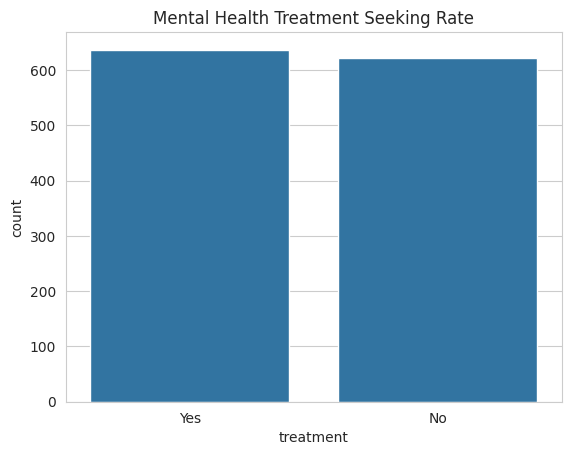

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sns.countplot(data=df, x="treatment")
plt.title("Mental Health Treatment Seeking Rate")
plt.show()

## Burnout by Company Size

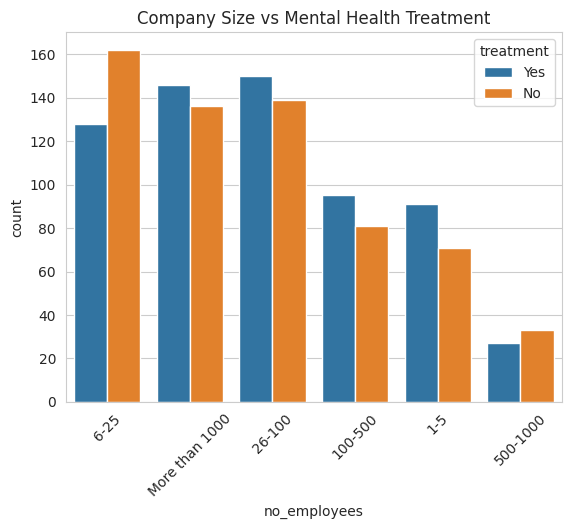

In [6]:
sns.countplot(data=df, x="no_employees", hue="treatment")
plt.xticks(rotation=45)
plt.title("Company Size vs Mental Health Treatment")
plt.show()

## Remote Work vs Mental Health

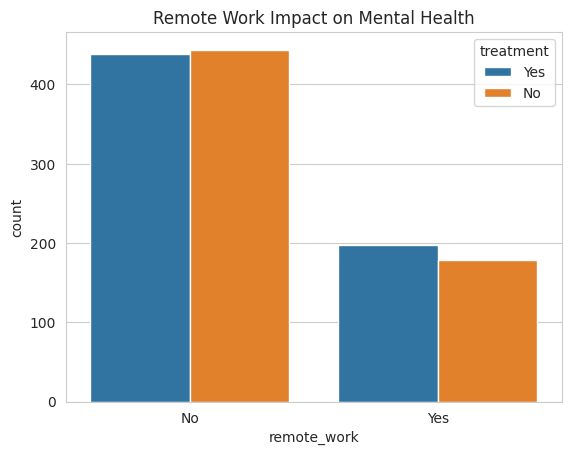

In [7]:
sns.countplot(data=df, x="remote_work", hue="treatment")
plt.title("Remote Work Impact on Mental Health")
plt.show()

## Gender Breakdown

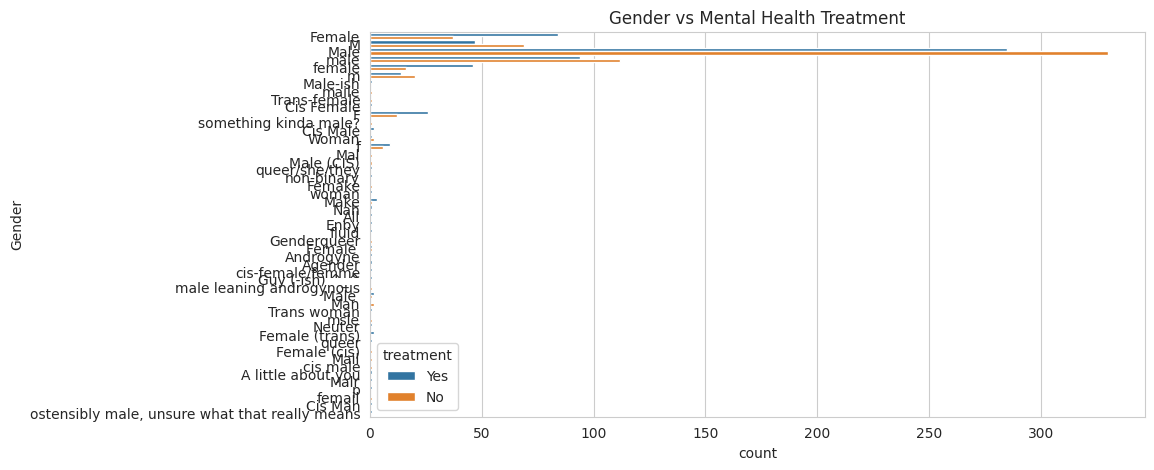

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="Gender", hue="treatment")
plt.title("Gender vs Mental Health Treatment")
plt.show()

## Work Interference Patterns

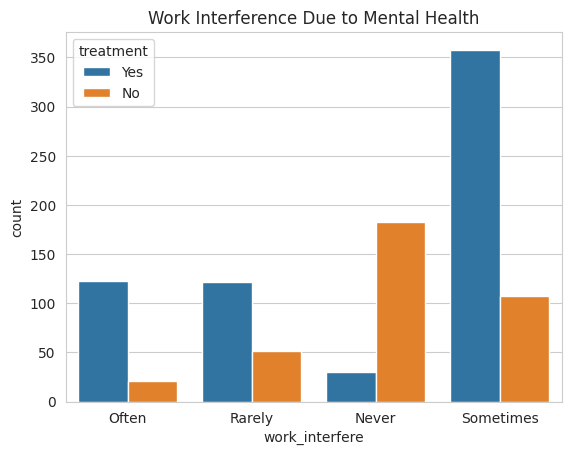

In [9]:
sns.countplot(data=df, x="work_interfere", hue="treatment")
plt.title("Work Interference Due to Mental Health")
plt.show()

# Feature Engineering

## Feature Creation

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df = df[df["Age"] < 100]  # remove outliers

In [11]:
size_map = {
    "1-5": 0,
    "6-25": 1,
    "26-100": 2,
    "100-500": 3,
    "500-1000": 4,
    "More than 1000": 5
}

df["no_employees"] = df["no_employees"].map(size_map)

## Remote Work Encoding

In [12]:
df["remote_work"] = df["remote_work"].map({"Yes": 1, "No": 0})

In [13]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 65, 120],
    labels=["Gen Z", "Young Adult", "Adult", "Mid Career", "Senior"]
)

## Encode Target + Categoricals

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Gender", "Country", "state", "AgeGroup", "work_interfere"]:
    df[col] = le.fit_transform(df[col].astype(str))

df["treatment"] = df["treatment"].map({"Yes": 1, "No": 0})

# XGBoost Model

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

## Feature Selection

In [16]:
features = [
    "Age",
    "Gender",
    "Country",
    "state",
    "no_employees",
    "remote_work",
    "family_history",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "work_interfere",
    "AgeGroup"
]

X = df[features]
y = df["treatment"]

## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training

In [20]:
# 1. Convert all 'object' (string) columns to 'category'
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    # Do the same for test/validation data if you have it:
    # X_val[col] = X_val[col].astype('category')

# 2. Add enable_categorical=True to your classifier
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=True  
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:

for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype('category')


preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       125
           1       0.81      0.88      0.84       127

    accuracy                           0.83       252
   macro avg       0.84      0.83      0.83       252
weighted avg       0.84      0.83      0.83       252



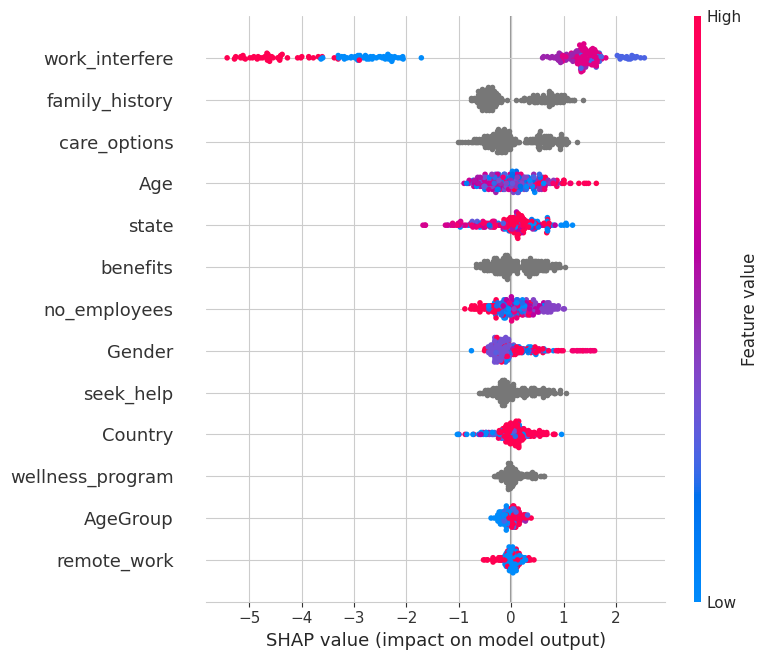

In [24]:
import shap

# 1. Initialize the explainer
explainer = shap.TreeExplainer(model)

# 2. Use the entire test set instead of sampling 300 rows
sample = X_test  

# 3. Calculate SHAP values and plot
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)


# Key Interpretation

Expected strongest burnout drivers:


* Work interference
* Lack of company mental health support
* Remote work conditions
* Family mental health historyCompany size


# Conclusion 

### Key Insights
* Workplace support strongly impacts mental health outcomes
* Employees in larger companies report different stress patterns
* Work interference is a dominant burnout indicator
* ML models can help proactively detect at-risk employees

## Real-World Impact

HR teams should:

* Improve mental health benefits visibility
* Encourage safe disclosure of mental health issues
* Monitor high-risk employee segments
* Use AI-based screening tools responsibly

## Connect With Me


* Website: nudratabbas.com
* Follow for more AI + Healthcare + HR analytics projects